In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import phys_grad, compute_core_mean, add_region_column


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [3]:
# df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_beta_data_w.pkl')
# df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
# df_eddies = df_eddies.merge(
#     df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
#     how='left',
#     left_on=['Eddy', 'Day'],
#     right_on=['Eddy', 'Day']
# )
# df_eddies = add_region_column(
#     df_eddies,
#     X_grid, Y_grid,
#     lon_rho, lat_rho,
#     h, mask_rho
# )
df_AE = df_eddies[df_eddies.Cyc=='AE'].copy().dropna()
df_CE = df_eddies[df_eddies.Cyc=='CE'].copy().dropna()
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,dh_dE,plan_beta,topo_beta_y,topo_beta_x,PV_grad_y,PV_grad_x,PV_grad_mag,topo_beta_mag,plan_beta_mag,beta_ratio
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.003523,-1.331380e-14,-7.887971e-14,1.413757e-13,-9.219350e-14,1.413757e-13,1.687801e-13,1.618922e-13,1.331380e-14,-1.084924
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.003795,-1.313568e-14,-8.552943e-14,1.475934e-13,-9.866511e-14,1.475934e-13,1.775348e-13,1.705846e-13,1.313568e-14,-1.113487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125221,2929,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,0.000934,-4.034582e-15,-2.731860e-15,5.151963e-15,-6.766441e-15,5.151963e-15,8.504555e-15,5.831448e-15,4.034582e-15,-0.159978
125222,2929,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,0.000879,-4.028122e-15,-1.353575e-15,4.882747e-15,-5.381697e-15,4.882747e-15,7.266628e-15,5.066891e-15,4.028122e-15,-0.099639
125223,2929,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125224,2929,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Potential-vorticity gradient including eddy vorticity

Starting from the barotropic potential vorticity,

$$
PV = \frac{\omega + f}{h},
$$

where $\omega$ is the relative vorticity, $f$ is the Coriolis parameter, and $h$ is the local water depth.

Rather than neglecting relative vorticity entirely, we assume that its horizontal gradients are small compared with the planetary and bathymetric contributions,

$$
\frac{\partial \omega}{\partial x} \approx 0,
\qquad
\frac{\partial \omega}{\partial y} \approx 0.
$$

Under this approximation,

$$
\frac{\partial PV}{\partial x}
=
-\frac{\omega+f}{h^2}\frac{\partial h}{\partial x},
$$

and

$$
\frac{\partial PV}{\partial y}
=
\frac{1}{h}\frac{\partial f}{\partial y}
-\frac{\omega+f}{h^2}\frac{\partial h}{\partial y}.
$$

Since

$$
\beta = \frac{\partial f}{\partial y},
$$

the horizontal PV gradient becomes

$$
\nabla PV
=
\left(
-\frac{\omega+f}{h^2}\frac{\partial h}{\partial x},
\;
\frac{\beta}{h}
-\frac{\omega+f}{h^2}\frac{\partial h}{\partial y}
\right).
$$

The magnitude of the PV gradient is

$$
|\nabla PV|
=
\sqrt{
\left(\frac{\partial PV}{\partial x}\right)^2
+
\left(\frac{\partial PV}{\partial y}\right)^2
}.
$$

This provides a scalar measure of the total environmental PV gradient experienced by an eddy.

The direction (bearing) of the PV gradient can be defined as

$$
\theta_{PV}
=
\tan^{-1}
\left(
\frac{\partial PV/\partial y}
     {\partial PV/\partial x}
\right),
$$

which allows direct comparison with the eddy tilt direction through

$$
\Delta\theta
=
\theta_{\rm tilt}
-
\theta_{PV}.
$$

Under this framework, both planetary vorticity and the eddy's own relative vorticity contribute to the topographic PV-gradient term through the factor $(\omega+f)$, while only the planetary component contributes to the meridional PV gradient through $\beta$.


In [4]:
# --------------------------------------------------
# Bathymetry and Coriolis
# --------------------------------------------------
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))

# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=h,
#     colname="h"
# )

# df_eddies['f'] = f[df_eddies.ic, df_eddies.jc]

# --------------------------------------------------
# Potential vorticity magnitude
# PV = (omega + f) / h
# --------------------------------------------------
# df_eddies['PV'] = (df_eddies['w'] + df_eddies['f']) / df_eddies['h']
# df_eddies['PV_mag'] = np.abs(df_eddies['PV'])

# --------------------------------------------------
# Grid gradients
# --------------------------------------------------
dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
dhdx, dhdy = phys_grad(h, X_grid*1e3, Y_grid*1e3, mask_rho)

df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)

dh_dN = -(np.sin(angle) * dhdx + np.cos(angle) * dhdy)
dh_dE = -(np.cos(angle) * dhdx - np.sin(angle) * dhdy)

# --------------------------------------------------
# Core-average gradient quantities
# --------------------------------------------------
# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=df_dN,
#     colname="beta"
# )

# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=dh_dN,
#     colname="dh_dN"
# )

# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=dh_dE,
#     colname="dh_dE"
# )

# --------------------------------------------------
# PV-gradient components including eddy vorticity
# assume d(omega)/dx = d(omega)/dy = 0
# --------------------------------------------------
# abs_vort = df_eddies['w'] + df_eddies['f']

# df_eddies['plan_beta'] = df_eddies['beta'] / df_eddies['h']

# df_eddies['topo_beta_y'] = (
#     -abs_vort / df_eddies['h']**2 * df_eddies['dh_dN']
# )

# df_eddies['topo_beta_x'] = (
#     -abs_vort / df_eddies['h']**2 * df_eddies['dh_dE']
# )

# df_eddies['PV_grad_y'] = df_eddies['plan_beta'] + df_eddies['topo_beta_y']
# df_eddies['PV_grad_x'] = df_eddies['topo_beta_x']

# df_eddies['PV_grad_mag'] = np.hypot(
#     df_eddies['PV_grad_x'],
#     df_eddies['PV_grad_y']
# )

# df_eddies['topo_beta_mag'] = np.hypot(
#     df_eddies['topo_beta_x'],
#     df_eddies['topo_beta_y']
# )

# df_eddies['plan_beta_mag'] = np.abs(df_eddies['plan_beta'])

# --------------------------------------------------
# Planetary vs topographic dominance ratio
# --------------------------------------------------
# df_eddies['beta_ratio'] = np.log10(
#     df_eddies['plan_beta_mag'] / df_eddies['topo_beta_mag']
# )

# df_eddies.loc[~np.isfinite(df_eddies['beta_ratio']), 'beta_ratio'] = np.nan

# df_eddies.to_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_beta_data_w.pkl')


In [5]:
# # fields
# beta = df_dN

# # planetary contribution
# plan_beta = df_dN / h

# # absolute vorticity
# abs_vort = w + f   # w must be on the same grid as f/h, otherwise do this eddy-by-eddy

# # topographic contribution including eddy vorticity
# topo_beta_y = -abs_vort / h**2 * dh_dN
# topo_beta_x = -abs_vort / h**2 * dh_dE

# # magnitudes
# plan_beta_mag = np.abs(plan_beta)
# topo_beta_mag = np.hypot(topo_beta_x, topo_beta_y)

# # total PV-gradient components
# PV_grad_y = plan_beta + topo_beta_y
# PV_grad_x = topo_beta_x
# PV_grad_mag = np.hypot(PV_grad_x, PV_grad_y)

# # dominance ratio: positive = planetary dominates, negative = topographic dominates
# log_ratio = np.log10(plan_beta_mag / topo_beta_mag)
# log_ratio[~np.isfinite(log_ratio)] = np.nan


abs_vort = df_eddies['w'] + df_eddies['f']

df_eddies['topo_beta_y'] = -abs_vort / df_eddies['h']**2 * df_eddies['dh_dN']
df_eddies['topo_beta_x'] = -abs_vort / df_eddies['h']**2 * df_eddies['dh_dE']



In [6]:
def panel(df_eddies, xcol, xlabel, legend_key, ax=None, xlim=None, split=None,
          reg_lo_override=None, reg_hi_override=None, scatter=False,
          xlim_flag=False, styles=None, linfit=False, xp=(10,90)):

    if ax is None:
        fig, ax = plt.subplots()

    df_eddies = df_eddies.copy()

    # Convert masked arrays to normal arrays with NaNs
    df_eddies[xcol] = np.ma.filled(np.ma.asarray(df_eddies[xcol]), np.nan)
    df_eddies['TiltDis'] = np.ma.filled(np.ma.asarray(df_eddies['TiltDis']), np.nan)

    if styles is None:
        styles = {
            'AE': {'line': 'darkred', 'fill': 'red'},
            'CE': {'line': 'navy',    'fill': 'blue'}
        }

    df_all = df_eddies.dropna(subset=[xcol])
    x = df_all[xcol].to_numpy(dtype=float)
    x_min, x_max = np.nanmin(x), np.nanmax(x)

    nbins = min(30, max(8, int(np.sqrt(len(x)))))
    bins = np.unique(np.nanquantile(x, np.linspace(0, 1, nbins + 1)))

    if len(bins) < 3:
        bins = np.linspace(x_min, x_max, 9)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for cyc in ['AE', 'CE']:
        dfm = df_eddies[df_eddies.Cyc == cyc].dropna(subset=[xcol, 'TiltDis'])

        xval = dfm[xcol].to_numpy(dtype=float)
        tilt = dfm['TiltDis'].to_numpy(dtype=float)

        mask = np.isfinite(xval) & np.isfinite(tilt)
        xval, tilt = xval[mask], tilt[mask]

        mask = (xval >= x_min) & (xval <= x_max)
        xval, tilt = xval[mask], tilt[mask]

        d = np.digitize(xval, bins)

        med = np.array([
            np.nanmedian(tilt[d == i]) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        q25 = np.array([
            np.nanquantile(tilt[d == i], 0.25) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        q75 = np.array([
            np.nanquantile(tilt[d == i], 0.75) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])

        if scatter:
            ax.scatter(xval, tilt, s=1, alpha=0.08, color=styles[cyc]['fill'])

        msk = np.isfinite(med)

        ax.plot(
            bin_centers[msk], med[msk],
            lw=3,
            color=styles[cyc]['line'],
            alpha=.6
        )

        ax.fill_between(
            bin_centers[msk],
            q25[msk],
            q75[msk],
            color=styles[cyc]['fill'],
            alpha=0.10
        )
        if linfit:
            if split is None:
                lo, hi = np.nanpercentile(xval, [10, 90])
                reg_mask = (xval >= lo) & (xval <= hi)
    
                if reg_mask.sum() > 2:
                    m, c, *_ = linregress(xval[reg_mask], tilt[reg_mask])
                    xf = np.linspace(lo, hi, 200)
    
                    ax.plot(
                        xf, m * xf + c,
                        '--',
                        lw=3,
                        color=styles[cyc]['fill'],
                        label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.3g}'
                    )
    
            else:
                lo, hi = np.nanpercentile(xval, [10, 90])
                hi2 = reg_hi_override if reg_hi_override is not None else hi
                lo2 = reg_lo_override if reg_lo_override is not None else lo
    
                for l, (a, b) in enumerate(zip([lo2, split], [split, hi2])):
                    reg_mask = (xval >= a) & (xval <= b)
    
                    if reg_mask.sum() > 2:
                        m, c, *_ = linregress(xval[reg_mask], tilt[reg_mask])
                        xf = np.linspace(a, b, 200)
    
                        ax.plot(
                            xf, m * xf + c,
                            ':' if l == 0 else '--',
                            lw=3,
                            color=styles[cyc]['fill'],
                            label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.3g}'
                        )
            ax.legend(loc='upper right', ncol=2)

    if xlim is None:
        ax.set_xlim(*np.nanpercentile(df_eddies[xcol].to_numpy(dtype=float), [xp[0], xp[1]]))
        # ax.set_xlim(ax.get_xlim())
    else:
        ax.set_xlim(*xlim)

    if xlim_flag:
        ax.set_xlim(bin_centers.min(), bin_centers.max())


    ax.set_xlabel(xlabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    return ax
    

(0.0, 55.0)

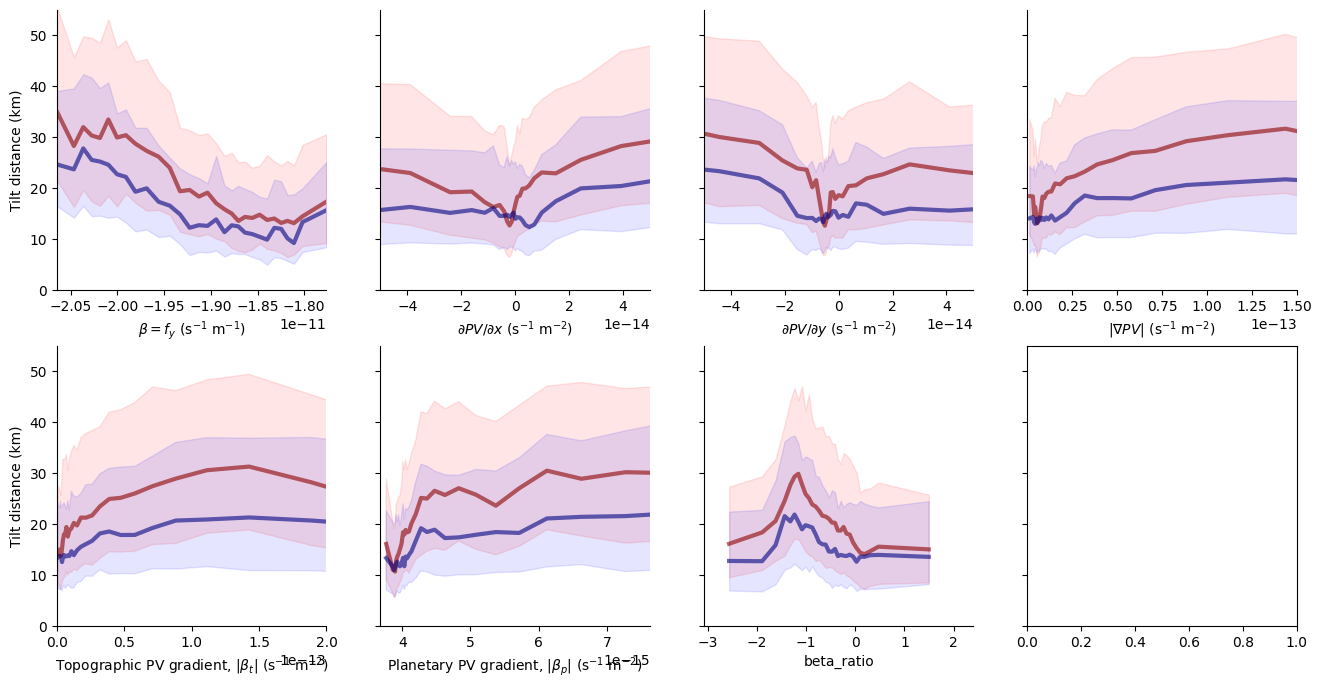

In [7]:
fig, axs = plt.subplots(2, 4, figsize=(16,8), sharey=True)
axs = axs.flatten()

xp = (5,95)

ax = axs[0]
panel(
    df_eddies,
    'beta',
    r'$\beta=f_y$ (s$^{-1}$ m$^{-1}$)',
    r'$\beta$',
    ax=ax,
    xlim_flag=True,
    scatter=False,
    xlim=(0,100)
    # xp=xp,
)
ax.set_ylabel('Tilt distance (km)')


ax = axs[1]
panel(
    df_eddies,
    'PV_grad_x',
    r'$\partial PV/\partial x$ (s$^{-1}$ m$^{-2}$)',
    r'$PV_x$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    # xp=(10,90)
    xlim=(-5e-14, 5e-14)
)


ax = axs[2]
panel(
    df_eddies,
    'PV_grad_y',
    r'$\partial PV/\partial y$ (s$^{-1}$ m$^{-2}$)',
    r'$PV_y$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    # xp=(10,90)
    xlim=(-5e-14, 5e-14)
)


ax = axs[3]
panel(
    df_eddies,
    'PV_grad_mag',
    r'$|\nabla PV|$ (s$^{-1}$ m$^{-2}$)',
    r'$|\nabla PV|$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xlim=(0,1.5e-13)
    # xp=(0,90)
)


ax = axs[4]
panel(
    df_eddies,
    'topo_beta_mag',
    r'Topographic PV gradient, $|\beta_t|$ (s$^{-1}$ m$^{-2}$)',
    r'$|\beta_t|$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xlim=(0,2e-13)
)
ax.set_ylabel('Tilt distance (km)')


ax = axs[5]
panel(
    df_eddies,
    'plan_beta_mag',
    r'Planetary PV gradient, $|\beta_p|$ (s$^{-1}$ m$^{-2}$)',
    r'$|\beta_p|$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xp=(0,90)
)

ax = axs[6]
panel(
    df_eddies,
    'beta_ratio',
    r'beta_ratio',
    r'$|\beta_p|$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xp=(0,100)
)

axs[0].set_ylim(0,55)
# plt.tight_layout()


 #### PV gradient direction!

In [8]:
# --------------------------------------------------
# Direction of horizontal PV gradient per eddy-day
# --------------------------------------------------

PVx = df_eddies['PV_grad_x'].values
PVy = df_eddies['PV_grad_y'].values

# Standard mathematical angle: 0=east, 90=north
theta_math = np.degrees(np.arctan2(PVy, PVx))

# Convert to compass bearing: 0=north, 90=east
df_eddies['theta_PV'] = (90 - theta_math) % 360

# Remove invalid values
bad = ~np.isfinite(PVx) | ~np.isfinite(PVy)
df_eddies.loc[bad, 'theta_PV'] = np.nan

# Compare with tilt direction
# Signed angular difference, wrapped to [-180, 180]
df_eddies['dtheta_PV'] = (
    (df_eddies['TiltDir'] - df_eddies['theta_PV'] + 180) % 360
) - 180

# Absolute angular difference, [0, 180]
df_eddies['abs_dtheta_PV'] = np.abs(df_eddies['dtheta_PV'])


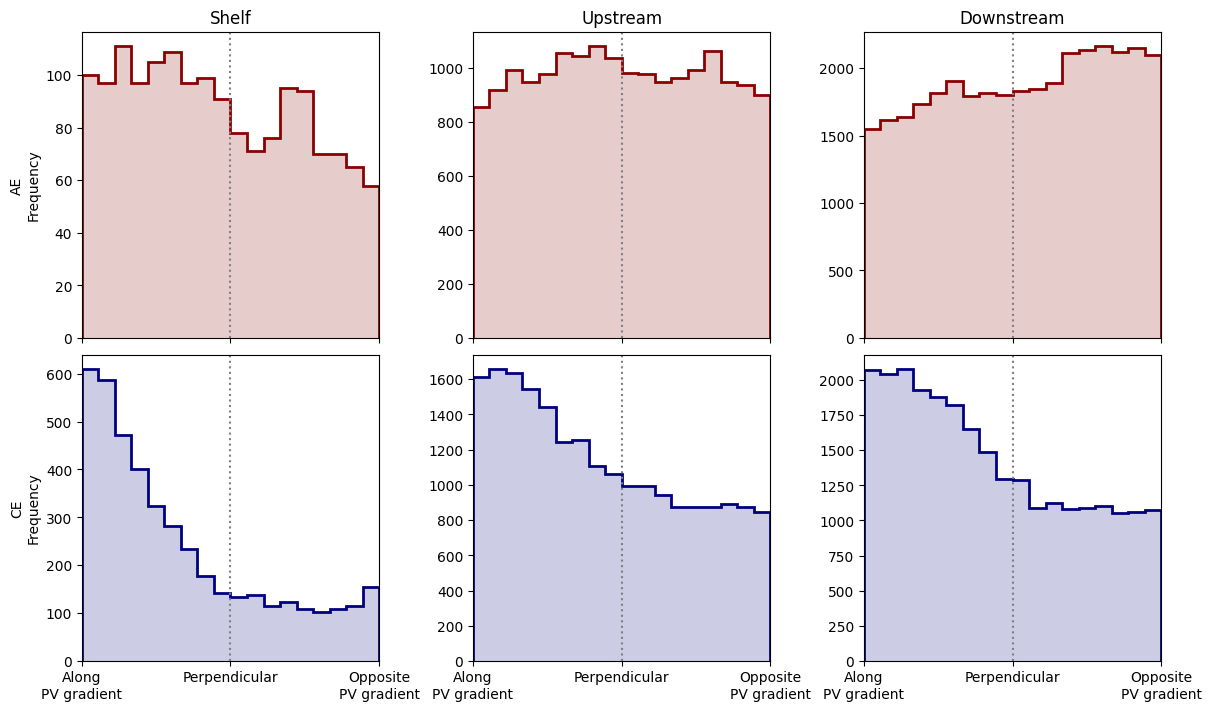

In [9]:
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(
    2, 3,
    figsize=(12, 7),
    sharex=True,
    # sharey=True,
    constrained_layout=True
)

regions = [
    ['S1', 'S2'],
    ['U1', 'U2'],
    ['D1', 'D2']
]

titles = ['Shelf', 'Upstream', 'Downstream']

for i, cyc in enumerate(['AE', 'CE']):

    for j, regs in enumerate(regions):

        ax = axs[i, j]

        df = df_eddies[
            (df_eddies.Cyc == cyc) &
            (df_eddies.Region.isin(regs))
        ]

        vals = df['abs_dtheta_PV'].dropna()

        color = 'darkred' if cyc == 'AE' else 'navy'

        ax.hist(
            vals,
            bins=bins,
            histtype='stepfilled',
            alpha=0.2,
            color=color
        )

        ax.hist(
            vals,
            bins=bins,
            histtype='step',
            linewidth=2,
            color=color
        )

        ax.axvline(90, color='grey', ls=':')

        if i == 0:
            ax.set_title(titles[j])

        if j == 0:
            ax.set_ylabel(f'{cyc}\nFrequency')

        ax.set_xlim(0, 180)

for ax in axs[-1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Along\nPV gradient',
        'Perpendicular',
        'Opposite\nPV gradient'
    ])

plt.show()


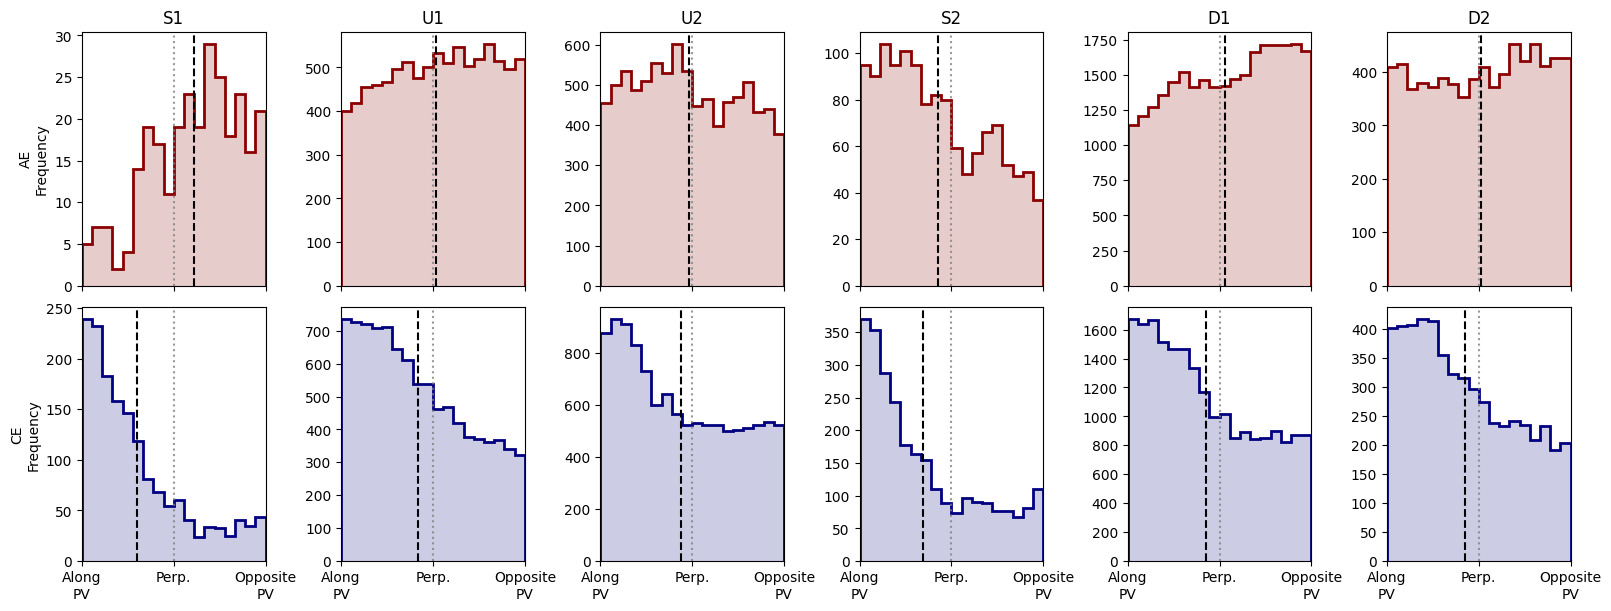

In [19]:
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(
    2, 6,
    figsize=(16, 6),
    sharex=True,
    # sharey=True,
    constrained_layout=True
)

region_order = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

for i, cyc in enumerate(['AE', 'CE']):

    color = 'darkred' if cyc == 'AE' else 'navy'

    for j, region in enumerate(region_order):

        ax = axs[i, j]

        vals = df_eddies.loc[
            (df_eddies.Cyc == cyc) &
            (df_eddies.Region == region),
            'abs_dtheta_PV'
        ].dropna()

        ax.hist(
            vals,
            bins=bins,
            histtype='stepfilled',
            alpha=0.2,
            color=color
        )

        ax.hist(
            vals,
            bins=bins,
            histtype='step',
            linewidth=2,
            color=color
        )

        mean_val = np.nanmean(vals)
        ax.axvline(
            mean_val,
            color='k',
            lw=1.5,
            ls='--'
        )

        ax.axvline(90, color='grey', ls=':', alpha=0.8)

        if i == 0:
            ax.set_title(region)

        if j == 0:
            ax.set_ylabel(f'{cyc}\nFrequency')

        if i == 1:
            ax.set_xticks([0, 90, 180])
            ax.set_xticklabels([
                'Along\nPV',
                'Perp.',
                'Opposite\nPV'
            ])

        ax.set_xlim(0, 180)

plt.show()


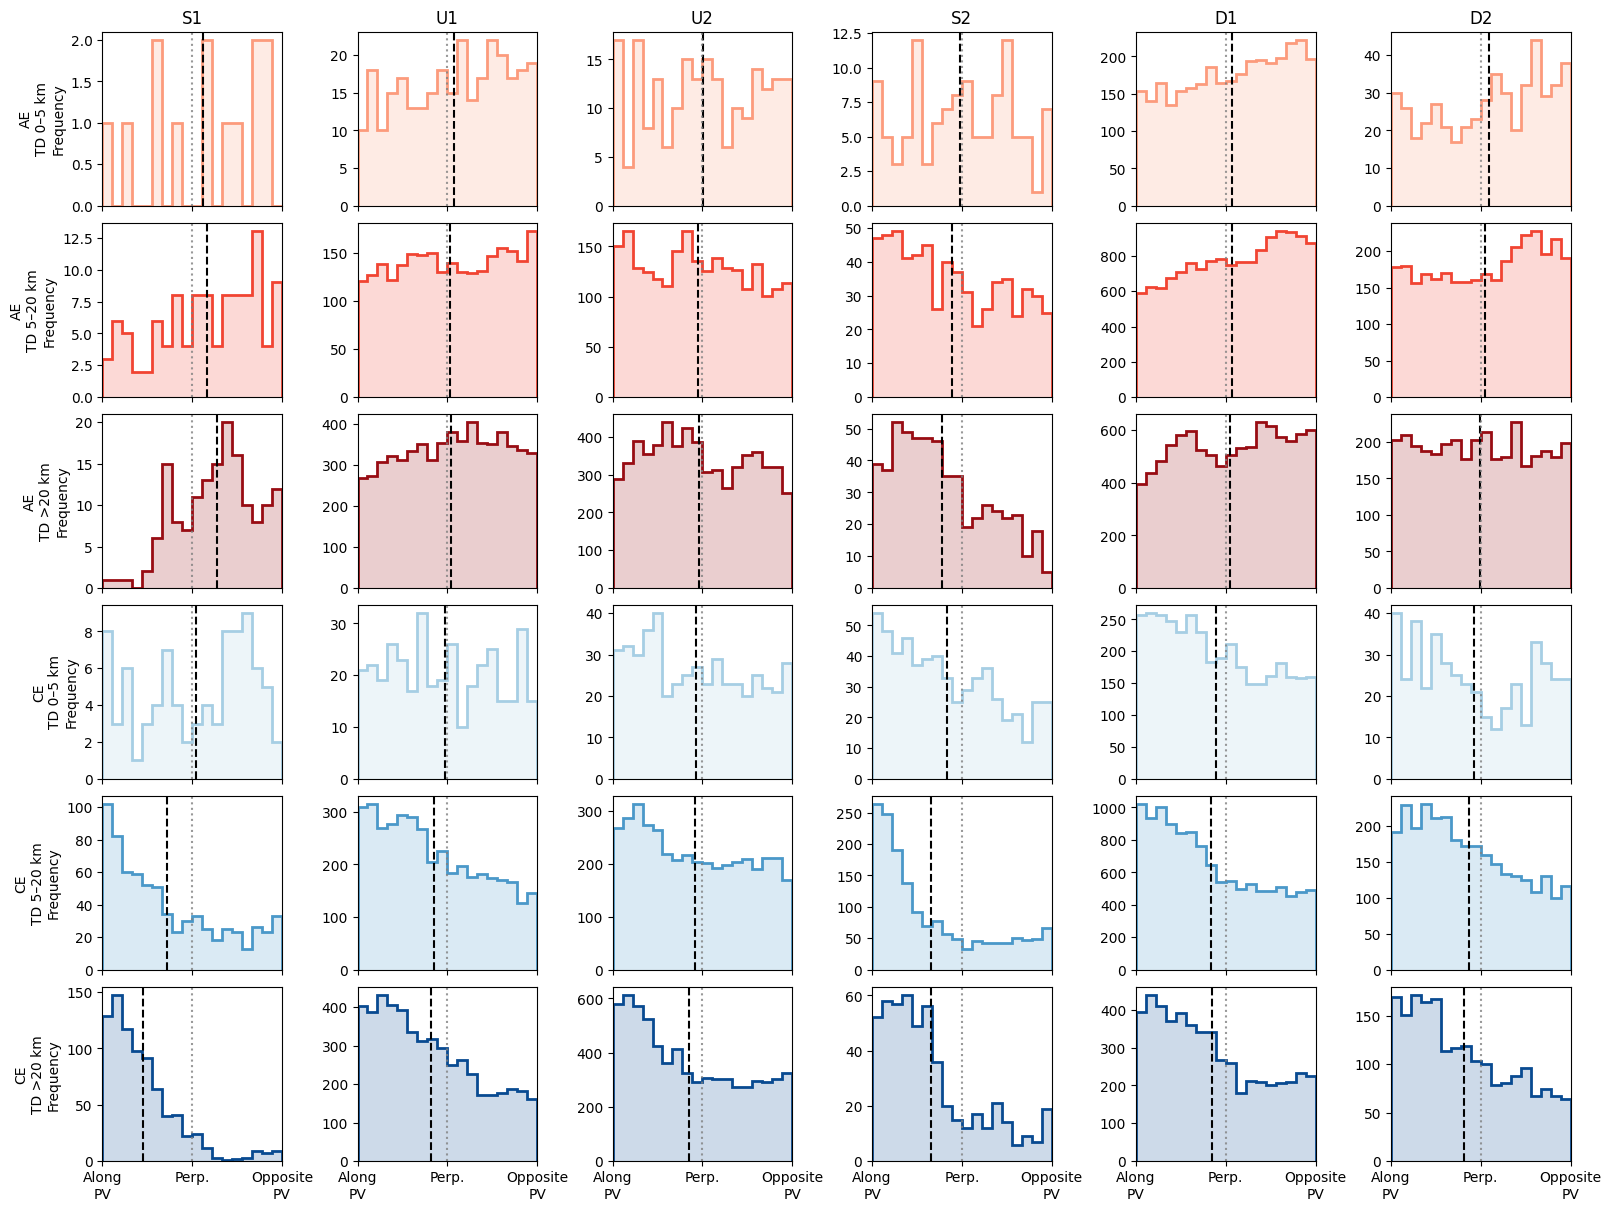

In [22]:
angle_bins = np.arange(0, 181, 10)

tilt_bins = [
    (0, 5, 'TD 0–5 km'),
    (5, 20, 'TD 5–20 km'),
    (20, np.inf, 'TD >20 km')
]

region_order = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

fig, axs = plt.subplots(
    6, 6,
    figsize=(16, 12),
    sharex=True,
    constrained_layout=True
)

for i, cyc in enumerate(['AE', 'CE']):

    # color = 'darkred' if cyc == 'AE' else 'navy'

    if cyc == 'AE':
        colors = [
            plt.get_cmap('Reds')(0.35),
            plt.get_cmap('Reds')(0.60),
            plt.get_cmap('Reds')(0.90)
        ]
    else:
        colors = [
            plt.get_cmap('Blues')(0.35),
            plt.get_cmap('Blues')(0.60),
            plt.get_cmap('Blues')(0.90)
        ]
    
    for k, (lo, hi, tilt_label) in enumerate(tilt_bins):

        row = i * len(tilt_bins) + k

        for j, region in enumerate(region_order):

            ax = axs[row, j]
            color = colors[k]

            vals = df_eddies.loc[
                (df_eddies.Cyc == cyc) &
                (df_eddies.Region == region) &
                (df_eddies.TiltDis >= lo) &
                (df_eddies.TiltDis < hi),
                'abs_dtheta_PV'
            ].dropna()

            ax.hist(
                vals,
                bins=angle_bins,
                histtype='stepfilled',
                alpha=0.2,
                color=color
            )

            ax.hist(
                vals,
                bins=angle_bins,
                histtype='step',
                linewidth=2,
                color=color
            )

            mean_val = np.nanmean(vals)

            ax.axvline(
                mean_val,
                color='k',
                lw=1.5,
                ls='--'
            )

            ax.axvline(90, color='grey', ls=':', alpha=0.8)
            ax.set_xlim(0, 180)

            if row == 0:
                ax.set_title(region)

            if j == 0:
                ax.set_ylabel(f'{cyc}\n{tilt_label}\nFrequency')

            if row == axs.shape[0] - 1:
                ax.set_xticks([0, 90, 180])
                ax.set_xticklabels(['Along\nPV', 'Perp.', 'Opposite\nPV'])

plt.show()
